# 1D Schwarz Alternating Domain Decomposition — PINN

**Method**: The domain $[0,1]$ is split into two overlapping sub-domains:
- $\Omega_1 = [0,\, b]$ with $b > 0.5$ (left sub-domain)
- $\Omega_2 = [a,\, 1]$ with $a < 0.5$ (right sub-domain)
- Overlap region: $[a, b]$

Each sub-domain gets its own PINN. The Schwarz iteration alternates:
1. Train $\text{PINN}_1$ on $\Omega_1$: uses fixed BCs at $x=0$ and an **interface BC at $x=b$** taken from the current $\text{PINN}_2$.
2. Train $\text{PINN}_2$ on $\Omega_2$: uses fixed BCs at $x=1$ and an **interface BC at $x=a$** taken from the updated $\text{PINN}_1$.
3. Repeat until convergence.

Four Poisson problems:
- Problem 1: $-u'' = \pi^2 \sin(\pi x)$, exact $u = \sin(\pi x)$
- Problem 2: $-u'' = 2$, exact $u = x(1-x)$
- Problem 3: $-u'' = 4\pi^2 \sin(2\pi x)$, exact $u = \sin(2\pi x)$
- Problem 4: $-u'' = -e^x$, exact $u = e^x$


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.12.0+cpu


## Network and Derivative Utilities

In [2]:
def create_model():
    """Same architecture as the original PINN."""
    return nn.Sequential(
        nn.Linear(1, 32), nn.Tanh(),
        nn.Linear(32, 32), nn.Tanh(),
        nn.Linear(32, 32), nn.Tanh(),
        nn.Linear(32, 1)
    )

def d2u_dx2(model, x):
    """Second derivative of model output w.r.t. x."""
    x = x.clone().detach().requires_grad_(True)
    u = model(x)
    du = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    d2u = torch.autograd.grad(du, x, grad_outputs=torch.ones_like(du), create_graph=True)[0]
    return d2u

## Sub-domain Training Function

In [3]:
def train_subdomain(
    model, f,
    x_left, u_left,
    x_right, u_right,
    x_lo, x_hi,
    epochs=800,
    n_collocation=500,
    lambda_bc=100.0,
    lr=1e-3,
    patience=150,
    min_delta=1e-7
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.9)

    x_bc = torch.tensor([[x_left], [x_right]], dtype=torch.float32)
    u_bc = torch.tensor([[u_left], [u_right]], dtype=torch.float32)

    best_loss = float('inf')
    patience_counter = 0
    history = []
    t0 = time.perf_counter()

    for epoch in range(epochs):
        x_int = (x_hi - x_lo) * torch.rand(n_collocation, 1) + x_lo
        x_int.requires_grad_(True)

        u = model(x_int)
        du = torch.autograd.grad(u, x_int, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        d2u = torch.autograd.grad(du, x_int, grad_outputs=torch.ones_like(du), create_graph=True)[0]
        L_pde = torch.mean((-d2u - f(x_int)) ** 2)

        u_pred_bc = model(x_bc)
        L_bc = torch.mean((u_pred_bc - u_bc) ** 2)

        loss = L_pde + lambda_bc * L_bc

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        history.append(loss.item())

        if loss.item() < best_loss - min_delta:
            best_loss = loss.item()
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= patience:
            break

    return history, time.perf_counter() - t0

## Schwarz Alternating Method

In [4]:
def schwarz_alternating(
    f,
    bc_left, bc_right,
    overlap_a=0.4,
    overlap_b=0.6,
    schwarz_iters=5,
    epochs_per_iter=800,   # 2 * 5 * 800 = 8000 total, same as PINN
    n_collocation=500,
    lambda_bc=100.0,
    lr=1e-3,
    patience=150,
    min_delta=1e-7,
    verbose=True
):
    x0, u0 = bc_left
    x1, u1 = bc_right

    # Created ONCE — warm-started across all Schwarz iters
    net1 = create_model()
    net2 = create_model()

    def get_interface_val(model, x_val):
        xt = torch.tensor([[x_val]], dtype=torch.float32)
        with torch.no_grad():
            return model(xt).item()

    u_at_a, u_at_b = 0.0, 0.0
    interface_vals = []
    loss_history = {'omega1': [], 'omega2': []}
    total_elapsed = 0.0

    for it in range(schwarz_iters):
        if verbose:
            print(f"\n── Schwarz iter {it+1}/{schwarz_iters} ──")

        h1, t1 = train_subdomain(
            net1, f,
            x_left=x0, u_left=u0,
            x_right=overlap_b, u_right=u_at_b,
            x_lo=x0, x_hi=overlap_b,
            epochs=epochs_per_iter, n_collocation=n_collocation,
            lambda_bc=lambda_bc, lr=lr, patience=patience, min_delta=min_delta
        )
        loss_history['omega1'].append(h1)
        total_elapsed += t1
        u_at_a = get_interface_val(net1, overlap_a)
        if verbose:
            print(f"  PINN1 ({len(h1)} epochs, {t1:.2f}s) | u(a={overlap_a}) = {u_at_a:.6f} | loss = {h1[-1]:.6f}")

        h2, t2 = train_subdomain(
            net2, f,
            x_left=overlap_a, u_left=u_at_a,
            x_right=x1, u_right=u1,
            x_lo=overlap_a, x_hi=x1,
            epochs=epochs_per_iter, n_collocation=n_collocation,
            lambda_bc=lambda_bc, lr=lr, patience=patience, min_delta=min_delta
        )
        loss_history['omega2'].append(h2)
        total_elapsed += t2
        u_at_b = get_interface_val(net2, overlap_b)
        if verbose:
            print(f"  PINN2 ({len(h2)} epochs, {t2:.2f}s) | u(b={overlap_b}) = {u_at_b:.6f} | loss = {h2[-1]:.6f}")

        interface_vals.append({'iter': it+1, 'u_at_a': u_at_a, 'u_at_b': u_at_b})

    return net1, net2, interface_vals, total_elapsed, loss_history

## Evaluation and Plotting

In [5]:
def evaluate_schwarz(net1, net2, exact_fn, overlap_a=0.4, overlap_b=0.6, n=200):
    """
    Stitch net1 and net2 predictions across [0,1].
    In the overlap zone, use the average of both networks.
    """
    x = torch.linspace(0, 1, n).unsqueeze(1)
    with torch.no_grad():
        p1 = net1(x).numpy().squeeze()
        p2 = net2(x).numpy().squeeze()

    x_np = x.numpy().squeeze()
    u_pred = np.where(
        x_np <= overlap_a, p1,
        np.where(
            x_np >= overlap_b, p2,
            0.5 * p1 + 0.5 * p2   # blend in overlap region
        )
    )

    u_exact = exact_fn(x).numpy().squeeze()
    error = np.abs(u_pred - u_exact)

    metrics = {
        'max_err':  np.max(error),
        'mean_err': np.mean(error),
        'rel_l2':   np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
    }
    print(f"  Max Absolute Error : {metrics['max_err']:.6f}")
    print(f"  Mean Absolute Error: {metrics['mean_err']:.6f}")
    print(f"  Relative L2 Error  : {metrics['rel_l2']:.6f}")
    return x_np, u_pred, u_exact, error, metrics


def plot_schwarz(x, u_pred, u_exact, error, loss_history, interface_vals,
                 overlap_a, overlap_b, problem_name, elapsed):
    fig, axs = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f"{problem_name}  |  Total time: {elapsed:.2f}s", fontsize=13, fontweight='bold')

    # Panel 1: Solution
    axs[0].plot(x, u_exact, label='Exact', color='blue', lw=2)
    axs[0].plot(x, u_pred, label='Schwarz PINN', color='red', linestyle='--', lw=1.5)
    axs[0].axvspan(overlap_a, overlap_b, alpha=0.15, color='green', label='Overlap')
    axs[0].axvline(overlap_a, color='green', lw=0.8, linestyle=':')
    axs[0].axvline(overlap_b, color='green', lw=0.8, linestyle=':')
    axs[0].set_title('Solution')
    axs[0].set_xlabel('x'); axs[0].legend(fontsize=8)

    # Panel 2: Error
    axs[1].plot(x, error, color='crimson')
    axs[1].axvspan(overlap_a, overlap_b, alpha=0.15, color='green')
    axs[1].set_title('Absolute Error'); axs[1].set_xlabel('x')

    # Panel 3: Training Loss per Schwarz iter
    colors1 = plt.cm.Blues(np.linspace(0.4, 0.9, len(loss_history['omega1'])))
    colors2 = plt.cm.Oranges(np.linspace(0.4, 0.9, len(loss_history['omega2'])))
    for k, (h1, h2) in enumerate(zip(loss_history['omega1'], loss_history['omega2'])):
        lbl1 = f'Ω₁ iter {k+1}' if k == 0 or k == len(loss_history['omega1'])-1 else None
        lbl2 = f'Ω₂ iter {k+1}' if k == 0 or k == len(loss_history['omega1'])-1 else None
        axs[2].semilogy(h1, color=colors1[k], alpha=0.85, label=lbl1)
        axs[2].semilogy(h2, color=colors2[k], alpha=0.85, label=lbl2, linestyle='--')
    axs[2].set_title('Loss per Schwarz iter'); axs[2].set_xlabel('Epoch')
    axs[2].legend(fontsize=7)

    # Panel 4: Interface value convergence
    iters = [v['iter'] for v in interface_vals]
    ua = [v['u_at_a'] for v in interface_vals]
    ub = [v['u_at_b'] for v in interface_vals]
    axs[3].plot(iters, ua, 'o-', color='steelblue', label=f'u(a={overlap_a})')
    axs[3].plot(iters, ub, 's--', color='darkorange', label=f'u(b={overlap_b})')
    axs[3].set_title('Interface Value Convergence'); axs[3].set_xlabel('Schwarz iter')
    axs[3].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## Schwarz Configuration

| Parameter | Value | Notes |
|---|---|---|
| `overlap_a` | 0.4 | Left edge of overlap (right BC for Ω₁) |
| `overlap_b` | 0.6 | Right edge of overlap (left BC for Ω₂) |
| `schwarz_iters` | 5 | Number of alternating sweeps |
| `epochs_per_iter` | 2000 | Training epochs per sub-domain per sweep |
| `n_collocation` | 500 | Collocation points per sub-domain |
| `lambda_bc` | 100 | BC penalty weight |

Total equivalent epochs = 2 × schwarz_iters × epochs_per_iter = **20 000** (same budget as original PINN's 8000 epochs but split into alternating sweeps).

In [6]:
OVERLAP_A = 0.4
OVERLAP_B = 0.6
SCHWARZ_ITERS = 5
EPOCHS_PER_ITER = 800   # 2 * 5 * 800 = 8000 total — equal to PINN budget
N_COLL = 500
LAMBDA_BC = 100.0
LR = 1e-3
PATIENCE = 150

timing_records = []

## Problem 1: Sine Wave
$-u'' = \pi^2 \sin(\pi x)$, $\;u(0)=u(1)=0$, $\;$ exact: $u(x)=\sin(\pi x)$


── Schwarz iter 1/5 ──
  PINN1 (800 epochs, 5.71s) | u(a=0.4) = 0.336536 | loss = 0.034599
  PINN2 (800 epochs, 5.47s) | u(b=0.6) = 0.540882 | loss = 0.002072

── Schwarz iter 2/5 ──
  PINN1 (800 epochs, 5.34s) | u(a=0.4) = 0.677530 | loss = 0.001183
  PINN2 (735 epochs, 3.50s) | u(b=0.6) = 0.768593 | loss = 0.000453

── Schwarz iter 3/5 ──
  PINN1 (800 epochs, 3.33s) | u(a=0.4) = 0.829328 | loss = 0.000723
  PINN2 (543 epochs, 2.51s) | u(b=0.6) = 0.869908 | loss = 0.000183

── Schwarz iter 4/5 ──
  PINN1 (800 epochs, 3.55s) | u(a=0.4) = 0.896910 | loss = 0.000327
  PINN2 (455 epochs, 2.17s) | u(b=0.6) = 0.914971 | loss = 0.000109

── Schwarz iter 5/5 ──
  PINN1 (800 epochs, 3.72s) | u(a=0.4) = 0.926993 | loss = 0.000088
  PINN2 (456 epochs, 1.97s) | u(b=0.6) = 0.935017 | loss = 0.000061

Total training time: 37.27s
  Max Absolute Error : 0.026055
  Mean Absolute Error: 0.012971
  Relative L2 Error  : 0.021786


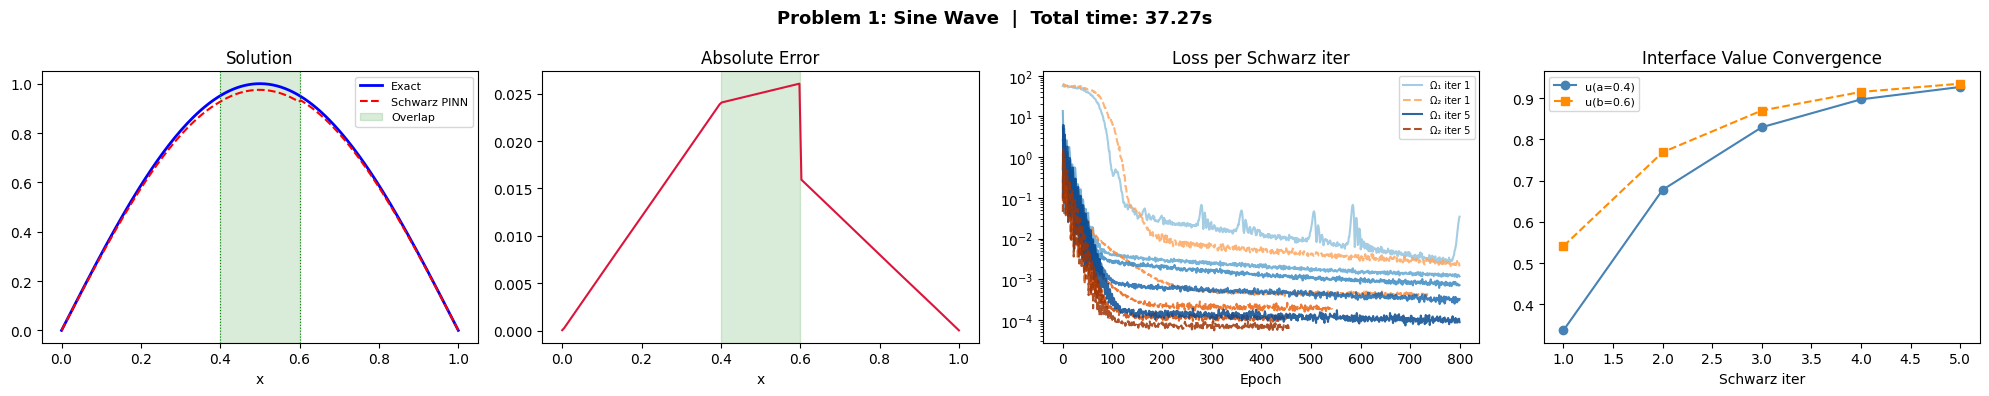

In [7]:
problem_name = "Problem 1: Sine Wave"
f       = lambda x: (torch.pi**2) * torch.sin(torch.pi * x)
exact   = lambda x: torch.sin(torch.pi * x)
bc_left  = (0.0, 0.0)
bc_right = (1.0, 0.0)

net1, net2, ivals, elapsed, lhist = schwarz_alternating(
    f, bc_left, bc_right,
    overlap_a=OVERLAP_A, overlap_b=OVERLAP_B,
    schwarz_iters=SCHWARZ_ITERS, epochs_per_iter=EPOCHS_PER_ITER,
    n_collocation=N_COLL, lambda_bc=LAMBDA_BC, lr=LR,
    patience=PATIENCE   # <-- add this line
)
print(f"\nTotal training time: {elapsed:.2f}s")
x, u_pred, u_exact, err, metrics = evaluate_schwarz(net1, net2, exact, OVERLAP_A, OVERLAP_B)
timing_records.append({'problem': problem_name, 'train_time_s': elapsed, **metrics})
plot_schwarz(x, u_pred, u_exact, err, lhist, ivals, OVERLAP_A, OVERLAP_B, problem_name, elapsed)

## Problem 2: Simple Polynomial
$-u'' = 2$, $\;u(0)=u(1)=0$, $\;$ exact: $u(x)=x(1-x)$


── Schwarz iter 1/5 ──
  PINN1 (800 epochs, 4.46s) | u(a=0.4) = 0.080432 | loss = 0.001118
  PINN2 (800 epochs, 7.20s) | u(b=0.6) = 0.132031 | loss = 0.004349

── Schwarz iter 2/5 ──
  PINN1 (800 epochs, 7.19s) | u(a=0.4) = 0.168048 | loss = 0.000098
  PINN2 (800 epochs, 5.58s) | u(b=0.6) = 0.192560 | loss = 0.000883

── Schwarz iter 3/5 ──
  PINN1 (770 epochs, 6.50s) | u(a=0.4) = 0.208316 | loss = 0.000095
  PINN2 (800 epochs, 6.65s) | u(b=0.6) = 0.219107 | loss = 0.000268

── Schwarz iter 4/5 ──
  PINN1 (390 epochs, 3.19s) | u(a=0.4) = 0.226019 | loss = 0.000113
  PINN2 (800 epochs, 6.09s) | u(b=0.6) = 0.230783 | loss = 0.000067

── Schwarz iter 5/5 ──
  PINN1 (337 epochs, 2.97s) | u(a=0.4) = 0.233780 | loss = 0.000130
  PINN2 (800 epochs, 5.76s) | u(b=0.6) = 0.235880 | loss = 0.000037

Total training time: 55.59s
  Max Absolute Error : 0.006667
  Mean Absolute Error: 0.003301
  Relative L2 Error  : 0.021616


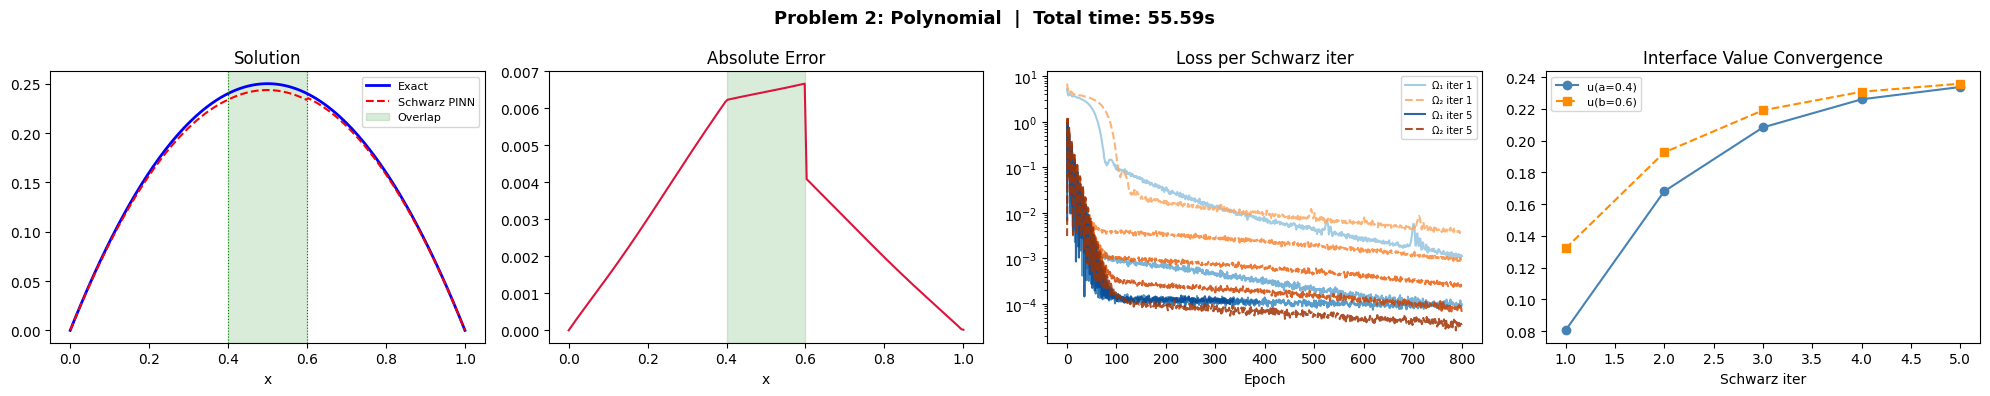

In [8]:
problem_name = "Problem 2: Polynomial"
f       = lambda x: 2.0 * torch.ones_like(x)
exact   = lambda x: x * (1 - x)
bc_left  = (0.0, 0.0)
bc_right = (1.0, 0.0)

net1, net2, ivals, elapsed, lhist = schwarz_alternating(
    f, bc_left, bc_right,
    overlap_a=OVERLAP_A, overlap_b=OVERLAP_B,
    schwarz_iters=SCHWARZ_ITERS, epochs_per_iter=EPOCHS_PER_ITER,
    n_collocation=N_COLL, lambda_bc=LAMBDA_BC, lr=LR,
    patience=PATIENCE   # <-- add this line
)
print(f"\nTotal training time: {elapsed:.2f}s")
x, u_pred, u_exact, err, metrics = evaluate_schwarz(net1, net2, exact, OVERLAP_A, OVERLAP_B)
timing_records.append({'problem': problem_name, 'train_time_s': elapsed, **metrics})
plot_schwarz(x, u_pred, u_exact, err, lhist, ivals, OVERLAP_A, OVERLAP_B, problem_name, elapsed)

## Problem 3: High-Frequency Sine
$-u'' = 4\pi^2 \sin(2\pi x)$, $\;u(0)=u(1)=0$, $\;$ exact: $u(x)=\sin(2\pi x)$


── Schwarz iter 1/5 ──
  PINN1 (800 epochs, 6.85s) | u(a=0.4) = 0.980698 | loss = 0.018848
  PINN2 (487 epochs, 4.75s) | u(b=0.6) = -0.324074 | loss = 0.018348

── Schwarz iter 2/5 ──
  PINN1 (800 epochs, 7.10s) | u(a=0.4) = 0.760734 | loss = 0.010346
  PINN2 (800 epochs, 5.92s) | u(b=0.6) = -0.470807 | loss = 0.003810

── Schwarz iter 3/5 ──
  PINN1 (321 epochs, 2.43s) | u(a=0.4) = 0.666381 | loss = 0.011813
  PINN2 (318 epochs, 2.64s) | u(b=0.6) = -0.535566 | loss = 0.002201

── Schwarz iter 4/5 ──
  PINN1 (287 epochs, 2.29s) | u(a=0.4) = 0.621487 | loss = 0.011632
  PINN2 (336 epochs, 2.45s) | u(b=0.6) = -0.565241 | loss = 0.002194

── Schwarz iter 5/5 ──
  PINN1 (349 epochs, 3.08s) | u(a=0.4) = 0.601161 | loss = 0.009507
  PINN2 (321 epochs, 2.97s) | u(b=0.6) = -0.579443 | loss = 0.002276

Total training time: 40.48s
  Max Absolute Error : 0.014983
  Mean Absolute Error: 0.006777
  Relative L2 Error  : 0.011732


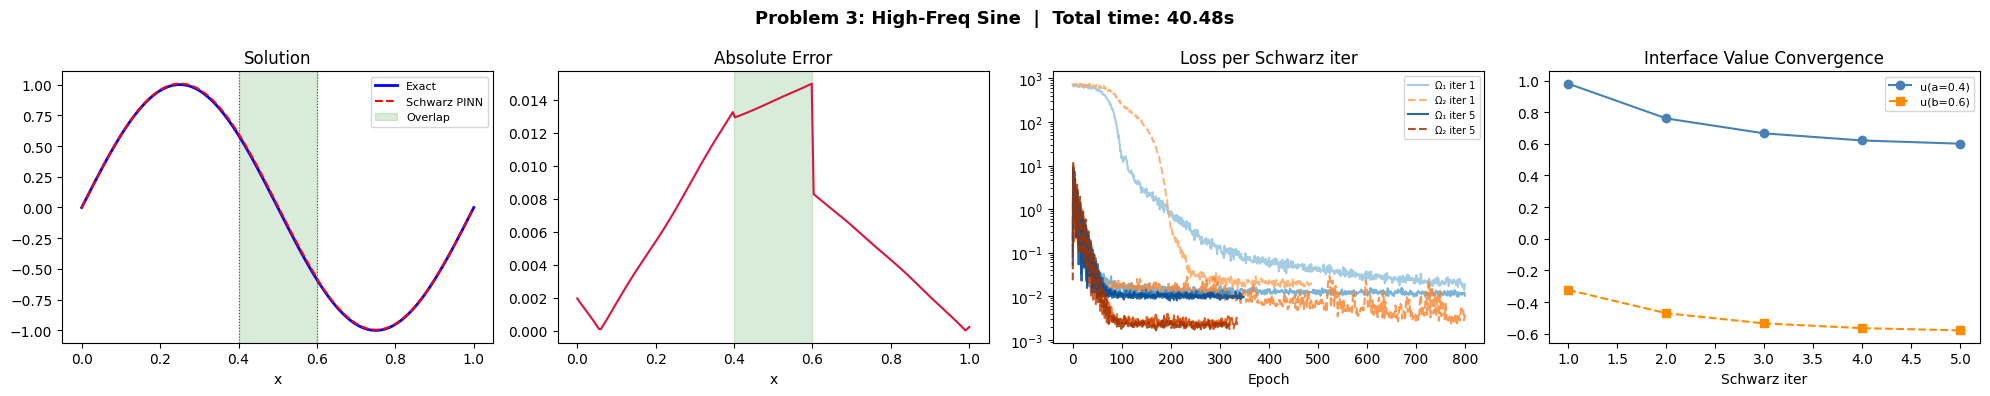

In [9]:
problem_name = "Problem 3: High-Freq Sine"
f       = lambda x: (4 * torch.pi**2) * torch.sin(2 * torch.pi * x)
exact   = lambda x: torch.sin(2 * torch.pi * x)
bc_left  = (0.0, 0.0)
bc_right = (1.0, 0.0)

net1, net2, ivals, elapsed, lhist = schwarz_alternating(
    f, bc_left, bc_right,
    overlap_a=OVERLAP_A, overlap_b=OVERLAP_B,
    schwarz_iters=SCHWARZ_ITERS, epochs_per_iter=EPOCHS_PER_ITER,
    n_collocation=N_COLL, lambda_bc=LAMBDA_BC, lr=LR,
    patience=PATIENCE   # <-- add this line
)
print(f"\nTotal training time: {elapsed:.2f}s")
x, u_pred, u_exact, err, metrics = evaluate_schwarz(net1, net2, exact, OVERLAP_A, OVERLAP_B)
timing_records.append({'problem': problem_name, 'train_time_s': elapsed, **metrics})
plot_schwarz(x, u_pred, u_exact, err, lhist, ivals, OVERLAP_A, OVERLAP_B, problem_name, elapsed)

## Problem 4: Exponential (Non-zero BCs)
$-u'' = -e^x$, $\;u(0)=1,\;u(1)=e$, $\;$ exact: $u(x)=e^x$


── Schwarz iter 1/5 ──
  PINN1 (800 epochs, 6.18s) | u(a=0.4) = 0.275469 | loss = 0.034091
  PINN2 (800 epochs, 7.83s) | u(b=0.6) = 1.011161 | loss = 0.013110

── Schwarz iter 2/5 ──
  PINN1 (800 epochs, 7.20s) | u(a=0.4) = 0.950405 | loss = 0.001877
  PINN2 (800 epochs, 8.59s) | u(b=0.6) = 1.460982 | loss = 0.000282

── Schwarz iter 3/5 ──
  PINN1 (785 epochs, 6.91s) | u(a=0.4) = 1.251000 | loss = 0.000798
  PINN2 (800 epochs, 6.28s) | u(b=0.6) = 1.661342 | loss = 0.000279

── Schwarz iter 4/5 ──
  PINN1 (800 epochs, 5.67s) | u(a=0.4) = 1.384682 | loss = 0.000488
  PINN2 (800 epochs, 6.36s) | u(b=0.6) = 1.750478 | loss = 0.000225

── Schwarz iter 5/5 ──
  PINN1 (800 epochs, 5.83s) | u(a=0.4) = 1.444018 | loss = 0.000277
  PINN2 (800 epochs, 6.30s) | u(b=0.6) = 1.790086 | loss = 0.000171

Total training time: 67.15s
  Max Absolute Error : 0.051832
  Mean Absolute Error: 0.025808
  Relative L2 Error  : 0.017091


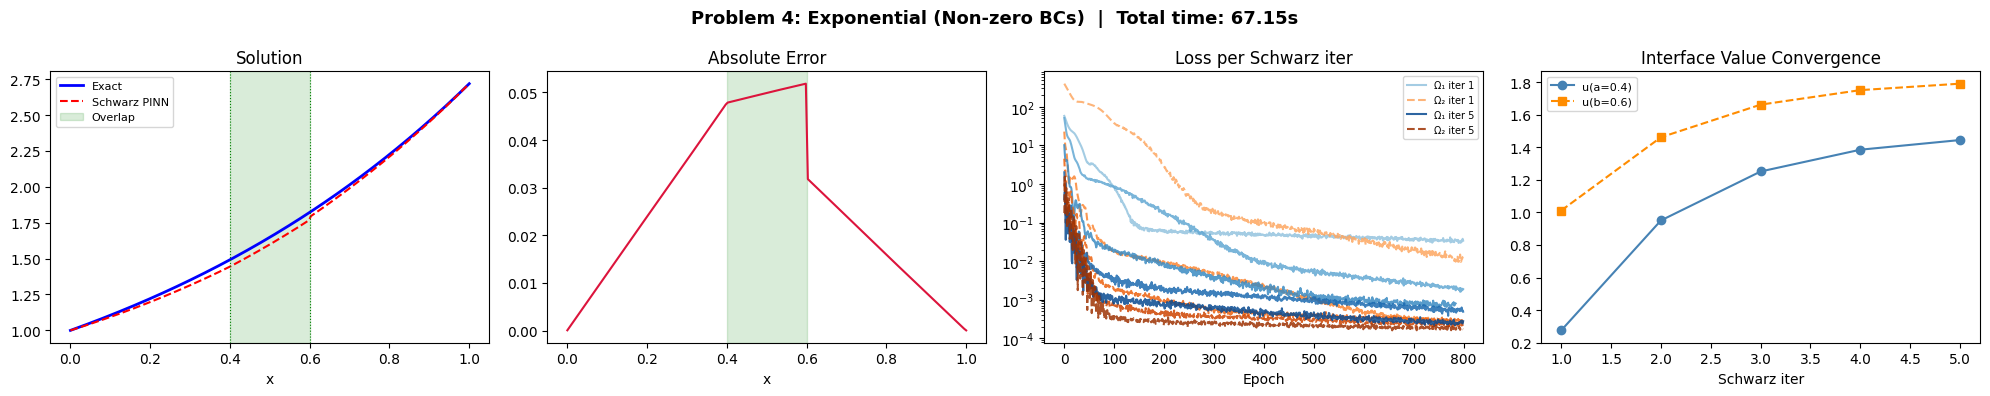

In [10]:
problem_name = "Problem 4: Exponential (Non-zero BCs)"
f       = lambda x: -torch.exp(x)
exact   = lambda x: torch.exp(x)
bc_left  = (0.0, 1.0)
bc_right = (1.0, float(torch.exp(torch.tensor(1.0)).item()))

net1, net2, ivals, elapsed, lhist = schwarz_alternating(
    f, bc_left, bc_right,
    overlap_a=OVERLAP_A, overlap_b=OVERLAP_B,
    schwarz_iters=SCHWARZ_ITERS, epochs_per_iter=EPOCHS_PER_ITER,
    n_collocation=N_COLL, lambda_bc=LAMBDA_BC, lr=LR,
    patience=PATIENCE   # <-- add this line
)
print(f"\nTotal training time: {elapsed:.2f}s")
x, u_pred, u_exact, err, metrics = evaluate_schwarz(net1, net2, exact, OVERLAP_A, OVERLAP_B)
timing_records.append({'problem': problem_name, 'train_time_s': elapsed, **metrics})
plot_schwarz(x, u_pred, u_exact, err, lhist, ivals, OVERLAP_A, OVERLAP_B, problem_name, elapsed)

In [11]:
OVERLAP_A = -1.6
OVERLAP_B = -1.4
SCHWARZ_ITERS = 5
EPOCHS_PER_ITER = 800   # 2 * 5 * 800 = 8000 total — equal to PINN budget
N_COLL = 500
LAMBDA_BC = 100.0
LR = 1e-3
PATIENCE = 150



In [12]:
def schwarz_alternating(f_fn, bc_left, bc_right, overlap_a, overlap_b,
                        x_l=-3.0, x_r=0.0, # <-- FIX 1: Pass global domain bounds
                        schwarz_iters=5, epochs_per_iter=1000, n_collocation=1000,
                        lambda_bc=100, lr=0.001, patience=300):
    
    # Initialize models
    net1 = create_model()
    net2 = create_model()
    
    # FIX 2: Define subdomains based on actual min/max of overlap interfaces
    omega1_l, omega1_r = x_l, max(overlap_a, overlap_b)
    omega2_l, omega2_r = min(overlap_a, overlap_b), x_r
    
    interface_vals = []
    loss_history = {'omega1': [], 'omega2': []}
    
    # Set up fixed external boundary targets
    xl_val, ul_val = bc_left
    xr_val, ur_val = bc_right

    start_time = time.perf_counter()
    
    for s_iter in range(schwarz_iters):
        print(f"--- Schwarz Iteration {s_iter+1}/{schwarz_iters} ---")
        
        # ==========================================
        # 1. Train Subdomain 1 (Omega 1)
        # ==========================================
        # Interface BC at the right side of Omega 1 taken from current Net 2
        with torch.no_grad():
            u_interface_r = net2(torch.tensor([[omega1_r]], dtype=torch.float32)).item()
        
        x_bc1 = torch.tensor([[omega1_l], [omega1_r]], dtype=torch.float32)
        u_bc1 = torch.tensor([[ul_val], [u_interface_r]], dtype=torch.float32)
        
        # Train Net 1
        opt1 = torch.optim.Adam(net1.parameters(), lr=lr)
        best_loss = float('inf')
        p_count = 0
        h1 = []
        

        for ep in range(epochs_per_iter):
            # FIX 3: Scale collocation points to safely fit Subdomain 1
            x_int = omega1_l + (omega1_r - omega1_l) * torch.rand((n_collocation, 1))
            x_int.requires_grad = True
            
            loss, pde_l, bc_l = compute_loss(net1, f_fn, x_int, x_bc1, u_bc1, lambda_bc)
            opt1.zero_grad(); loss.backward(); opt1.step()
            h1.append(loss.item())
            
            if loss.item() < best_loss - 1e-7: best_loss = loss.item(); p_count = 0
            else: p_count += 1
            if p_count >= patience: break
        

        
        loss_history['omega1'].append(h1)
        
        # ==========================================
        # 2. Train Subdomain 2 (Omega 2)
        # ==========================================
        # Interface BC at the left side of Omega 2 taken from updated Net 1
        with torch.no_grad():
            u_interface_l = net1(torch.tensor([[omega2_l]], dtype=torch.float32)).item()
            
        x_bc2 = torch.tensor([[omega2_l], [omega2_r]], dtype=torch.float32)
        u_bc2 = torch.tensor([[u_interface_l], [ur_val]], dtype=torch.float32)
        
        # Train Net 2
        opt2 = torch.optim.Adam(net2.parameters(), lr=lr)
        best_loss = float('inf')
        p_count = 0
        h2 = []
    
        for ep in range(epochs_per_iter):
            # FIX 4: Scale collocation points to safely fit Subdomain 2
            x_int = omega2_l + (omega2_r - omega2_l) * torch.rand((n_collocation, 1))
            x_int.requires_grad = True
            
            loss, pde_l, bc_l = compute_loss(net2, f_fn, x_int, x_bc2, u_bc2, lambda_bc)
            opt2.zero_grad(); loss.backward(); opt2.step()
            h2.append(loss.item())
            
            if loss.item() < best_loss - 1e-7: best_loss = loss.item(); p_count = 0
            else: p_count += 1
            if p_count >= patience: break
        loss_history['omega2'].append(h2)

        # Log convergence metrics at interface boundaries
        with torch.no_grad():
            ua = net1(torch.tensor([[overlap_a]], dtype=torch.float32)).item()
            ub = net2(torch.tensor([[overlap_b]], dtype=torch.float32)).item()
        interface_vals.append({'iter': s_iter+1, 'u_at_a': ua, 'u_at_b': ub})
        print(f"  Interface convergence -> u(a): {ua:.4f}, u(b): {ub:.4f}")
    
    end_time = time.perf_counter()
    total_time = end_time - start_time
        
    return net1, net2, interface_vals, total_time, loss_history # timer handled externally if needed

def compute_loss(model, f, x_interior, x_bc, u_bc, lambda_bc):
    # 1. Calculate PDE Loss (-u'' = f(x))
    u = model(x_interior)
    # First derivative
    du = torch.autograd.grad(u, x_interior, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    # Second derivative
    d2u = torch.autograd.grad(du, x_interior, grad_outputs=torch.ones_like(du), create_graph=True)[0]
    
    # Residual: -u'' - f(x) = 0
    pde_residual = -d2u - f(x_interior)
    pde_loss = torch.mean(pde_residual ** 2)
    
    # 2. Calculate Boundary Condition Loss
    u_pred_bc = model(x_bc)
    bc_loss = torch.mean((u_pred_bc - u_bc) ** 2)
    
    # 3. Total Loss
    total_loss = pde_loss + lambda_bc * bc_loss
    
    # Returning total_loss as a tensor for backprop, and the others as numbers for logging
    return total_loss, pde_loss.item(), bc_loss.item()

In [13]:
def evaluate_schwarz(net1, net2, exact_fn, overlap_a, overlap_b, x_l=-3.0, x_r=0.0, n=200):
    """
    Stitch net1 and net2 predictions across [x_l, x_r].
    In the overlap zone, use the average of both networks.
    """
    # FIX 1: Generate the test grid across your custom bounds
    x = torch.linspace(x_l, x_r, n).unsqueeze(1)
    with torch.no_grad():
        p1 = net1(x).numpy().squeeze()
        p2 = net2(x).numpy().squeeze()

    x_np = x.numpy().squeeze()
    
    # FIX 2: Adapt stitching logic for ordered subdomain bounds
    # Because overlap_b (-1.6) < overlap_a (-1.4), we use the smaller value for the left boundary
    v_min = min(overlap_a, overlap_b)
    v_max = max(overlap_a, overlap_b)
    
    u_pred = np.where(
        x_np <= v_min, p1,       # Region belonging entirely to Omega_1
        np.where(
            x_np >= v_max, p2,   # Region belonging entirely to Omega_2
            0.5 * p1 + 0.5 * p2  # Blend in overlap region
        )
    )

    u_exact = exact_fn(x).numpy().squeeze()
    error = np.abs(u_pred - u_exact)

    metrics = {
        'max_err':  np.max(error),
        'mean_err': np.mean(error),
        'rel_l2':   np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
    }
    print(f"  Max Absolute Error : {metrics['max_err']:.6f}")
    print(f"  Mean Absolute Error: {metrics['mean_err']:.6f}")
    print(f"  Relative L2 Error  : {metrics['rel_l2']:.6f}")
    
    return x_np, u_pred, u_exact, error, metrics

In [14]:
def plot_schwarz(x, u_pred, u_exact, error, loss_history, interface_vals,
                 overlap_a, overlap_b, problem_name, elapsed):
    fig, axs = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f"{problem_name}  |  Total time: {elapsed:.2f}s", fontsize=13, fontweight='bold')

    # FIX: Ensure min and max are ordered correctly for axvspan regardless of domain sign
    v_min = min(overlap_a, overlap_b)
    v_max = max(overlap_a, overlap_b)

    # Panel 1: Solution
    axs[0].plot(x, u_exact, label='Exact', color='blue', lw=2)
    axs[0].plot(x, u_pred, label='Schwarz PINN', color='red', linestyle='--', lw=1.5)
    axs[0].axvspan(v_min, v_max, alpha=0.15, color='green', label='Overlap')
    axs[0].axvline(overlap_a, color='green', lw=0.8, linestyle=':')
    axs[0].axvline(overlap_b, color='green', lw=0.8, linestyle=':')
    axs[0].set_title('Solution')
    axs[0].set_xlabel('x')
    axs[0].legend(fontsize=8)
    axs[0].grid(True, linestyle=':', alpha=0.6)

    # Panel 2: Error
    axs[1].plot(x, error, color='crimson')
    axs[1].axvspan(v_min, v_max, alpha=0.15, color='green')
    axs[1].set_title('Absolute Error')
    axs[1].set_xlabel('x')
    axs[1].grid(True, linestyle=':', alpha=0.6)

    # Panel 3: Training Loss per Schwarz iter
    colors1 = plt.cm.Blues(np.linspace(0.4, 0.9, len(loss_history['omega1'])))
    colors2 = plt.cm.Oranges(np.linspace(0.4, 0.9, len(loss_history['omega2'])))
    for k, (h1, h2) in enumerate(zip(loss_history['omega1'], loss_history['omega2'])):
        lbl1 = f'Ω₁ iter {k+1}' if k == 0 or k == len(loss_history['omega1'])-1 else None
        lbl2 = f'Ω₂ iter {k+1}' if k == 0 or k == len(loss_history['omega1'])-1 else None
        axs[2].semilogy(h1, color=colors1[k], alpha=0.85, label=lbl1)
        axs[2].semilogy(h2, color=colors2[k], alpha=0.85, label=lbl2, linestyle='--')
    axs[2].set_title('Loss per Schwarz iter')
    axs[2].set_xlabel('Epoch')
    axs[2].legend(fontsize=7)
    axs[2].grid(True, which="both", linestyle=':', alpha=0.4)

    # Panel 4: Interface value convergence
    iters = [v['iter'] for v in interface_vals]
    ua = [v['u_at_a'] for v in interface_vals]
    ub = [v['u_at_b'] for v in interface_vals]
    axs[3].plot(iters, ua, 'o-', color='steelblue', label=f'u(a={overlap_a:.2f})')
    axs[3].plot(iters, ub, 's--', color='darkorange', label=f'u(b={overlap_b:.2f})')
    axs[3].set_title('Interface Value Convergence')
    axs[3].set_xlabel('Schwarz iter')
    axs[3].legend(fontsize=8)
    axs[3].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

--- Schwarz Iteration 1/5 ---
  Interface convergence -> u(a): 0.2852, u(b): -0.1066
--- Schwarz Iteration 2/5 ---
  Interface convergence -> u(a): 0.1694, u(b): 0.0231
--- Schwarz Iteration 3/5 ---
  Interface convergence -> u(a): 0.2899, u(b): 0.0968
--- Schwarz Iteration 4/5 ---
  Interface convergence -> u(a): 0.3502, u(b): 0.1362
--- Schwarz Iteration 5/5 ---
  Interface convergence -> u(a): 0.3864, u(b): 0.1599
  Max Absolute Error : 0.030896
  Mean Absolute Error: 0.014290
  Relative L2 Error  : 0.021974


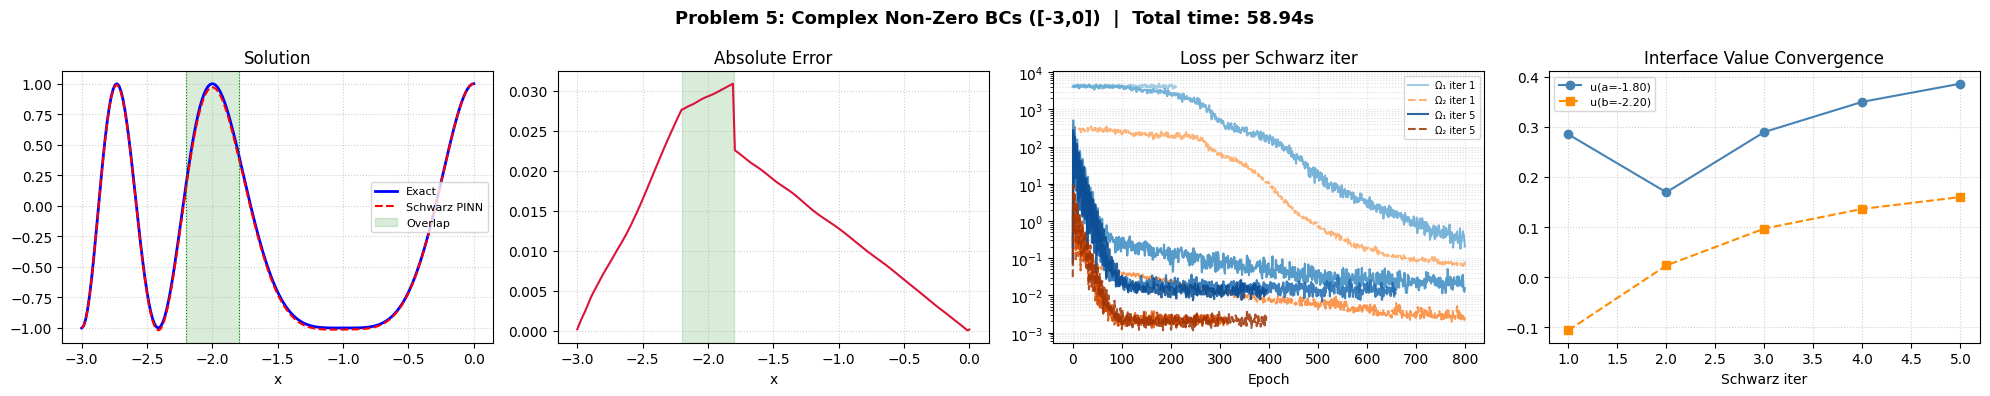

In [15]:
# Problem 5: Complex Non-Zero BCs (Updated Range: [-3, 0])
X_L = -3.0
X_R = 0.0
problem_name = "Problem 5: Complex Non-Zero BCs ([-3,0])"

f = lambda x: 2*torch.pi*torch.sin(torch.pi*x**2 + 2*torch.pi*x) + 4*(torch.pi**2)*(x + 1)**2*torch.cos(torch.pi*x**2 + 2*torch.pi*x)
exact = lambda x: torch.cos(torch.pi*x**2 + 2*torch.pi*x)

bc_left  = (X_L, -1.0)  # u(-3) = -1
bc_right = (X_R, 1.0)   # u(0) = 1

OVERLAP_A = -1.8
OVERLAP_B = -2.2  

# Update: passed explicit X_L and X_R bounds into the training algorithm
net1, net2, ivals, elapsed, lhist = schwarz_alternating(
    f, bc_left, bc_right,
    overlap_a=OVERLAP_A, overlap_b=OVERLAP_B,
    x_l=X_L, x_r=X_R,
    schwarz_iters=SCHWARZ_ITERS, epochs_per_iter=EPOCHS_PER_ITER,
    n_collocation=N_COLL, lambda_bc=LAMBDA_BC, lr=LR,
    patience=PATIENCE
)

x, u_pred, u_exact, err, metrics = evaluate_schwarz(
    net1, net2, exact, OVERLAP_A, OVERLAP_B, x_l=X_L, x_r=X_R
)
timing_records.append({'problem': problem_name, 'train_time_s': elapsed, **metrics})

plot_schwarz(x, u_pred, u_exact, err, lhist, ivals, OVERLAP_A, OVERLAP_B, "Problem 5: Complex Non-Zero BCs ([-3,0])", elapsed)

## Summary Table

In [16]:
print("\n" + "="*75)
print(f"{'Problem':<38} {'Time(s)':>8} {'Max Err':>10} {'Mean Err':>10} {'Rel L2':>9}")
print("="*75)
for r in timing_records:
    print(f"{r['problem']:<38} {r['train_time_s']:>8.2f} {r['max_err']:>10.6f} {r['mean_err']:>10.6f} {r['rel_l2']:>9.6f}")
print("="*75)
total = sum(r['train_time_s'] for r in timing_records)
print(f"{'TOTAL':.<38} {total:>8.2f}")


Problem                                 Time(s)    Max Err   Mean Err    Rel L2
Problem 1: Sine Wave                      37.27   0.026055   0.012971  0.021786
Problem 2: Polynomial                     55.59   0.006667   0.003301  0.021616
Problem 3: High-Freq Sine                 40.48   0.014983   0.006777  0.011732
Problem 4: Exponential (Non-zero BCs)     67.15   0.051832   0.025808  0.017091
Problem 5: Complex Non-Zero BCs ([-3,0])    58.94   0.030896   0.014290  0.021974
TOTAL.................................   259.43
